# Phase 1 — Modèle LSTM sur FD001

Objectif : entraîner un LSTM sur les fenêtres de capteurs (séquence complète, pas de features
agrégées comme pour la baseline), et comparer ses scores à ceux de
`04_baseline_fd001.ipynb` (test H1 du protocole : le deep learning apporte-t-il un gain
mesurable par rapport à une baseline classique ?).

Le pipeline de données (split, sélection de capteurs, normalisation, RUL plafonnée, fenêtrage)
est rigoureusement identique à celui de la baseline, même graine de split (42) : seule la
dernière étape change (pas d'agrégation, le LSTM voit la séquence brute).

Critère « fait » (plan d'exécution, Phase 1) : scores sur le val, comparaison à la baseline.

In [1]:
import sys
sys.path.append("..")

import matplotlib.pyplot as plt
import pandas as pd

from src.metrics import asymmetric_score, rmse
from src.preprocessing import add_piecewise_rul, compute_norm_stats, make_windows, normalize, select_features, split_by_unit
from src.torch_model import RULRegressor, set_seed, train_model

SEED = 42
WINDOW_SIZE = 30
RUL_CAP = 125

DATA_DIR = "../DATA/CMaps"
INDEX_NAMES = ["unit_number", "time_cycles"]
SETTING_NAMES = ["setting_1", "setting_2", "setting_3"]
SENSOR_NAMES = [f"sensor_{i}" for i in range(1, 22)]
COL_NAMES = INDEX_NAMES + SETTING_NAMES + SENSOR_NAMES

raw = pd.read_csv(f"{DATA_DIR}/train_FD001.txt", sep=r"\s+", header=None)
raw = raw.iloc[:, : len(COL_NAMES)]
raw.columns = COL_NAMES
raw.shape

(20631, 26)

In [2]:
train_raw, val_raw = split_by_unit(raw, val_fraction=0.2, seed=SEED)

selected_sensors = select_features(train_raw, SENSOR_NAMES, std_threshold=1e-2)
norm_stats = compute_norm_stats(train_raw, selected_sensors)

train_norm = normalize(train_raw, selected_sensors, norm_stats)
val_norm = normalize(val_raw, selected_sensors, norm_stats)

train_rul = add_piecewise_rul(train_norm, cap=RUL_CAP)
val_rul = add_piecewise_rul(val_norm, cap=RUL_CAP)

X_train, y_train, _ = make_windows(train_rul, selected_sensors, window_size=WINDOW_SIZE, target_col="RUL")
X_val, y_val, _ = make_windows(val_rul, selected_sensors, window_size=WINDOW_SIZE, target_col="RUL")

X_train.shape, X_val.shape

((14459, 30, 14), (3272, 30, 14))

In [3]:
set_seed(SEED)  # avant la construction du modèle : l'initialisation des poids en dépend
model = RULRegressor(n_features=len(selected_sensors), hidden_size=64)

model, history = train_model(model, X_train, y_train, X_val, y_val, epochs=50, lr=1e-3, batch_size=64, seed=SEED)
history_df = pd.DataFrame(history)
history_df.tail()

,epoch,train_loss,val_rmse
45,45,31.985713,16.803521
46,46,31.299821,16.807405
47,47,30.135658,16.754802
48,48,27.963489,16.557616
49,49,29.672000,16.879606


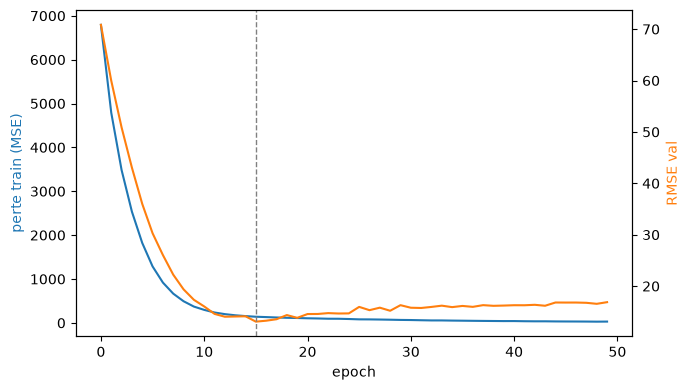

In [4]:
best_epoch = history_df["val_rmse"].idxmin()

fig, ax1 = plt.subplots(figsize=(7, 4))
ax1.plot(history_df["epoch"], history_df["train_loss"], color="tab:blue", label="perte train (MSE)")
ax1.set_xlabel("epoch")
ax1.set_ylabel("perte train (MSE)", color="tab:blue")

ax2 = ax1.twinx()
ax2.plot(history_df["epoch"], history_df["val_rmse"], color="tab:orange", label="RMSE val")
ax2.set_ylabel("RMSE val", color="tab:orange")
ax2.axvline(best_epoch, color="grey", linestyle="--", linewidth=1)

fig.tight_layout()

**Ce que montre cette figure** : en bleu, la perte d'entraînement (MSE) — elle doit baisser
de façon régulière, sinon l'optimisation ne fonctionne pas. En orange, le RMSE de validation —
c'est lui qui nous intéresse vraiment, puisqu'il mesure la généralisation. La ligne pointillée
grise marque l'epoch retenu (le meilleur sur le val) : si elle tombe bien avant la fin des 50
epochs, ça veut dire que le modèle a commencé à surapprendre après ce point (perte train qui
continue de baisser pendant que le RMSE val stagne ou remonte) — exactement le cas que le
mécanisme "on garde le meilleur epoch" est censé neutraliser.

In [5]:
import torch

model.eval()
with torch.no_grad():
    device = next(model.parameters()).device
    y_pred = model(torch.tensor(X_val, dtype=torch.float32, device=device)).cpu().numpy()

# Scores de la baseline, obtenus dans 04_baseline_fd001.ipynb (même split, même seed) :
# recopiés ici pour comparaison directe, pas recalculés, pour ne pas dupliquer leur code.
comparison = pd.DataFrame([
    {"modèle": "Régression linéaire", "RMSE": 21.536573, "score_asymétrique": 77665.928021},
    {"modèle": "Forêt aléatoire", "RMSE": 17.899715, "score_asymétrique": 29640.942003},
    {"modèle": "LSTM", "RMSE": rmse(y_val, y_pred), "score_asymétrique": asymmetric_score(y_val, y_pred)},
])
comparison

,modèle,RMSE,score_asymétrique
0,Régression linéaire,21.536573,77665.928021
1,Forêt aléatoire,17.899715,29640.942003
2,LSTM,13.088298,12245.140782


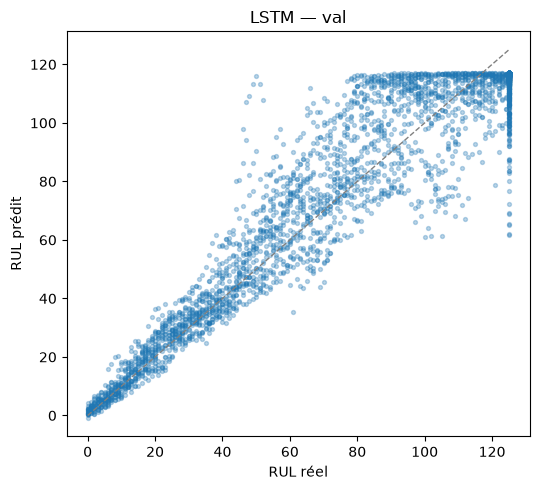

In [6]:
fig, ax = plt.subplots(figsize=(5.5, 5))
ax.scatter(y_val, y_pred, s=8, alpha=0.3)
ax.plot([0, RUL_CAP], [0, RUL_CAP], color="grey", linestyle="--", linewidth=1)
ax.set_xlabel("RUL réel")
ax.set_ylabel("RUL prédit")
ax.set_title("LSTM — val")
fig.tight_layout()

**Ce que montre cette figure** : même lecture que pour la baseline (`04_baseline_fd001.ipynb`)
— proximité à la diagonale = bonne prédiction, aplatissement près de 125 attendu en début de
vie. À comparer visuellement aux deux nuages de points de la baseline : c'est cette
comparaison, plus que le tableau de scores seul, qui permet de juger si le LSTM capture mieux
la dynamique de dégradation en fin de vie (RUL faible), là où le score asymétrique est le plus
sévère.

In [7]:
# Sauvegarde des poids (meilleur epoch déjà chargé dans model par train_model), pour pouvoir
# évaluer ce modèle précis sur le vrai test FD001 sans avoir à ré-entraîner dans ce notebook.
import os

os.makedirs("../models", exist_ok=True)
torch.save(model.state_dict(), "../models/lstm_fd001_seed42.pt")